# Connecticut Real Estate Market Analysis (2001–2021)

Looking at ~500K+ real estate transactions across all 169 towns in Connecticut. The raw data came from CT's open data portal and was loaded into PostgreSQL for querying. SQL did the heavy lifting for aggregation and window functions, Python reshaped the outputs, and this notebook handles the visualizations and final analysis.

**Goal:** Figure out which CT markets are the hottest, which ones are growing fastest, and where properties sell quickest.

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

In [5]:
# these CSVs are outputs from the SQL queries in /sql
transactions = pd.read_csv('../data/processed/transformed_transactions.csv')
changes = pd.read_csv('../data/processed/transformed_data.csv')
growth = pd.read_csv('../data/processed/5yr_growth_rate.csv')
days_market = pd.read_csv('../data/processed/days_on_market.csv')
sale_prices = pd.read_csv('../data/processed/transaction_sale_price_results.csv')

print(f"Transactions data: {len(transactions)} rows")
print(f"YoY Changes data: {len(changes)} rows")
print(f"Growth rate data: {len(growth)} rows")
print(f"Days on market data: {len(days_market)} rows")
print(f"Sale prices data: {len(sale_prices)} rows")

Transactions data: 840 rows
YoY Changes data: 840 rows
Growth rate data: 10 rows
Days on market data: 10 rows
Sale prices data: 23854 rows


## 1. Transaction Volume — Who's Busiest?

Starting with the basics. Which towns have the most real estate activity? This uses the past 5 years of data (roughly 2018-2022) since that's more useful than looking at the full 20-year span.

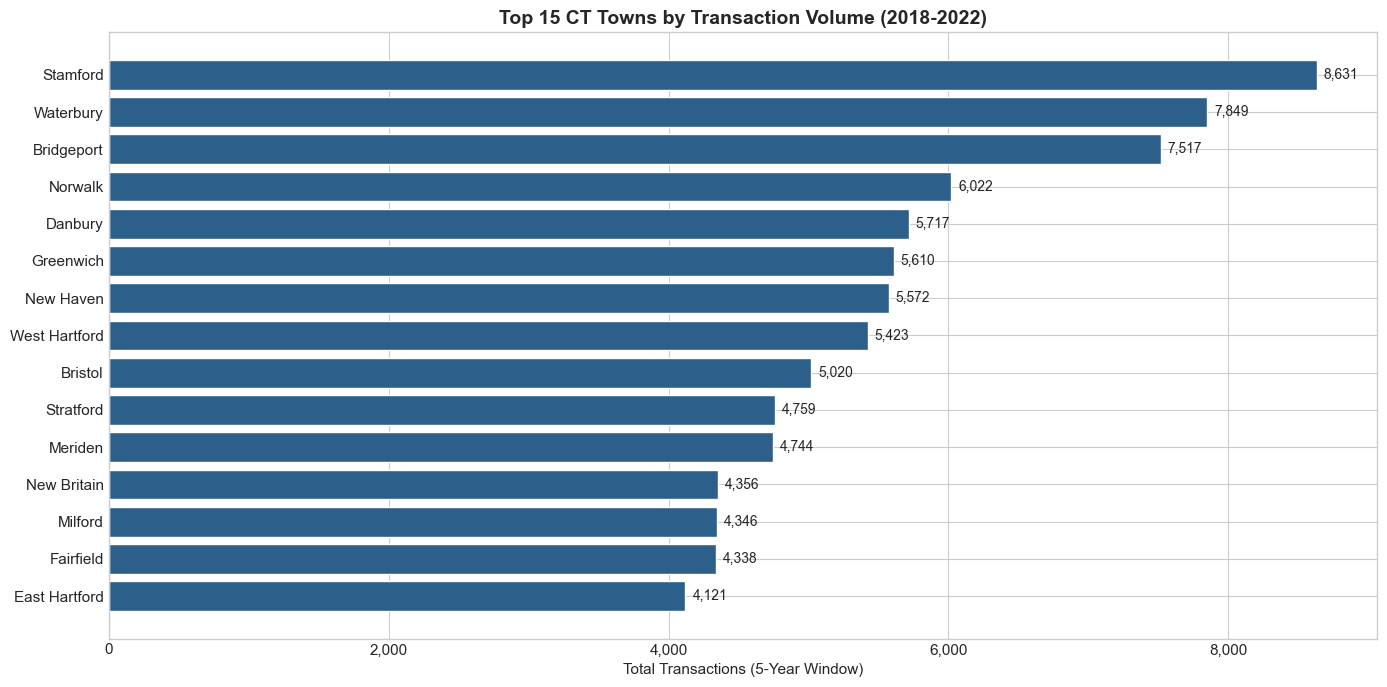

Top 5 markets make up 35,736 transactions
All 15 together: 84,025


In [7]:
# sum up transactions per town across the 5-year window
town_totals = transactions.groupby('Town')['Transactions'].sum().sort_values(ascending=False)
top_15 = town_totals.head(15)

fig, ax = plt.subplots(figsize=(14, 7))
bars = ax.barh(top_15.index[::-1], top_15.values[::-1], color='#2c5f8a', edgecolor='white')

for bar, val in zip(bars, top_15.values[::-1]):
    ax.text(bar.get_width() + 50, bar.get_y() + bar.get_height()/2,
            f'{int(val):,}', va='center', fontsize=10)

ax.set_xlabel('Total Transactions (5-Year Window)')
ax.set_title('Top 15 CT Towns by Transaction Volume (2018-2022)', fontweight='bold', fontsize=14)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.savefig('../images/top_towns_volume.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Top 5 markets make up {top_15.head(5).sum():,} transactions")
print(f"All 15 together: {top_15.sum():,}")

Stamford and Waterbury are clearly the two heaviest markets by raw volume. Not super surprising — Stamford is the financial hub of CT (basically NYC spillover) and Waterbury is one of the bigger cities. What's more interesting is seeing towns like Hamden and Southington up there, those are more suburban markets.

## 2. Transaction Trends Over Time

Now let's look at how things shifted year to year. Did markets grow? Shrink? The COVID years (2020-2021) should show up clearly here.

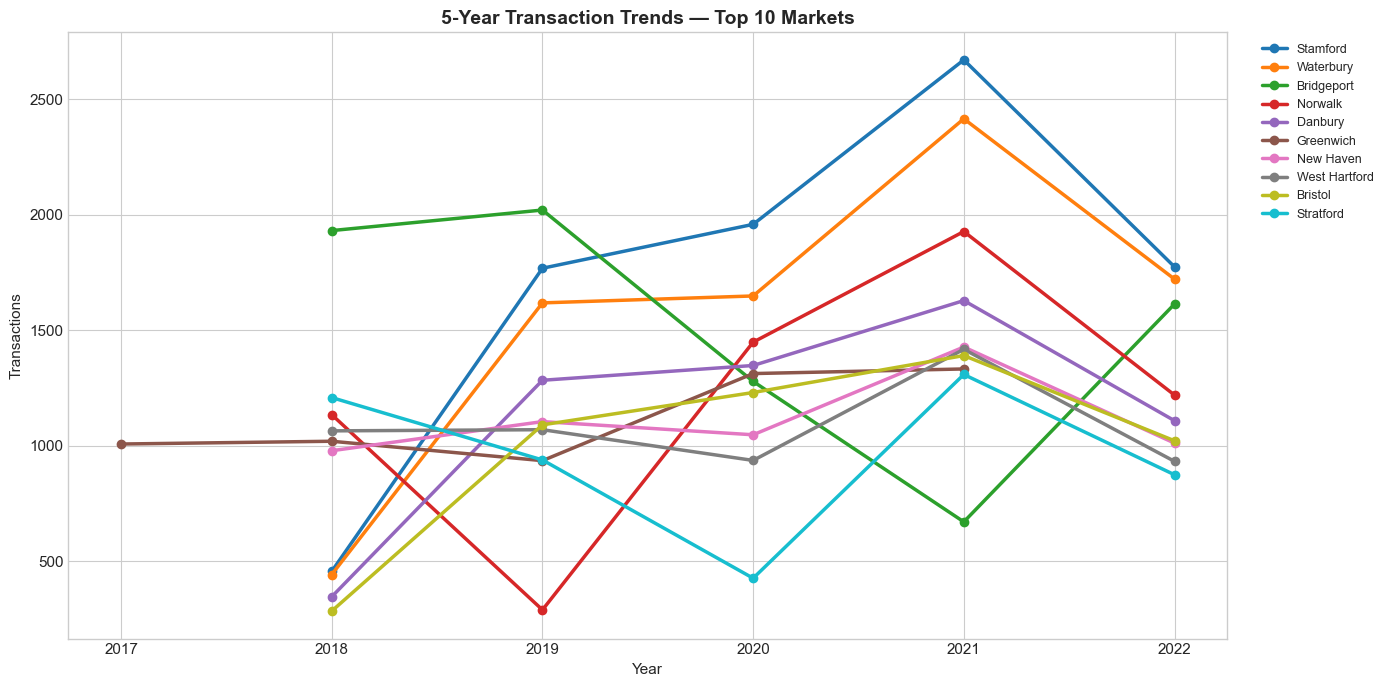

In [8]:
# get the top 10 towns by total volume
top_towns = town_totals.head(10).index.tolist()
trend_data = transactions[transactions['Town'].isin(top_towns)]

fig, ax = plt.subplots(figsize=(14, 7))

colors = plt.cm.tab10(np.linspace(0, 1, 10))
for i, town in enumerate(top_towns):
    town_df = trend_data[trend_data['Town'] == town].sort_values('Year')
    ax.plot(town_df['Year'], town_df['Transactions'], marker='o',
            linewidth=2.5, label=town, color=colors[i])

ax.set_xlabel('Year')
ax.set_ylabel('Transactions')
ax.set_title('5-Year Transaction Trends — Top 10 Markets', fontweight='bold', fontsize=14)
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=9)
ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
plt.tight_layout()
plt.savefig('../images/transaction_trends.png', dpi=150, bbox_inches='tight')
plt.show()

A few things pop out here:

1. **2020 dip to 2021 spike**: Almost every town shows this pattern. COVID shut things down in early 2020, then pent-up demand exploded in 2021. Classic.
2. **Bridgeport is weird**: It actually had MORE transactions in 2018-2019 and then dropped in 2020-2021 while everyone else spiked. Different market dynamics — possibly more affected by economic uncertainty.
3. **2022 pullback**: Most markets came back down in 2022, probably reflecting rising interest rates cooling things off.

## 3. Year-over-Year Changes

Same story but looking at the raw change numbers instead of totals. This makes it easier to spot which towns had the biggest swings.

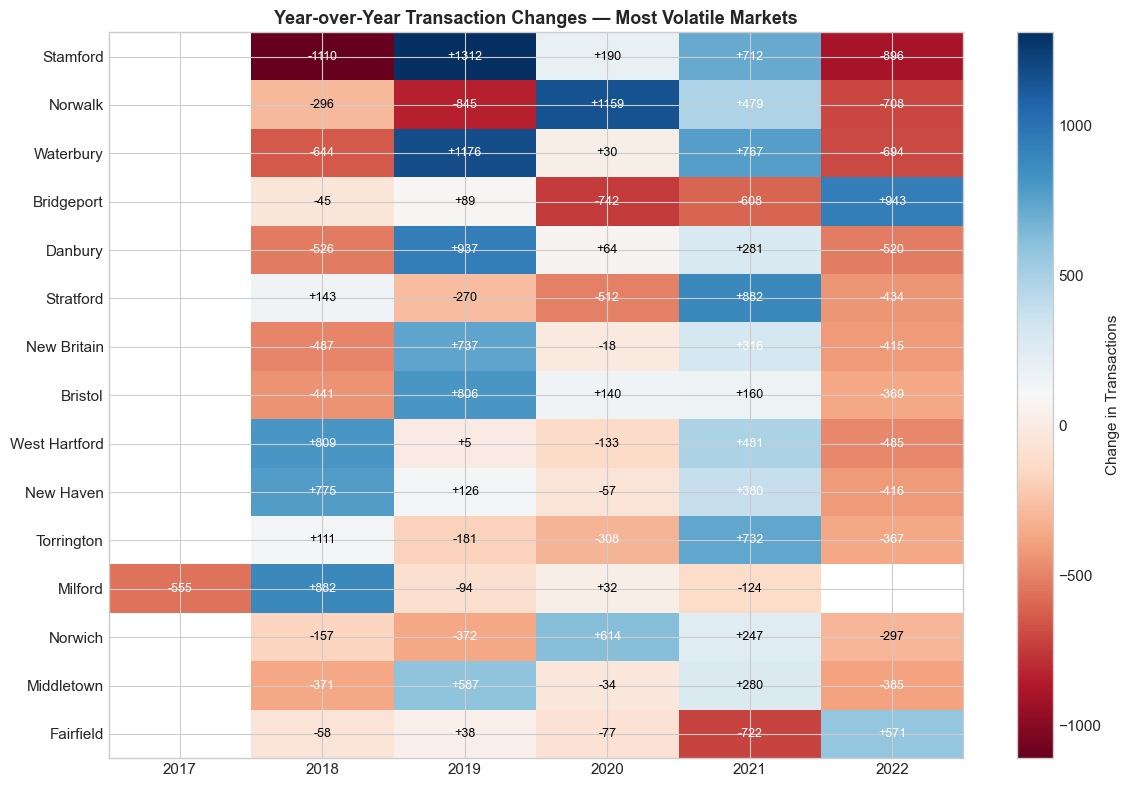

In [9]:
# pivot the change data into a heatmap-friendly format
change_pivot = changes.pivot_table(index='Town', columns='Year', values='Change', aggfunc='first')
change_pivot = change_pivot.sort_index()

# grab top 15 towns by absolute total change (most volatile markets)
change_pivot['abs_total'] = change_pivot.abs().sum(axis=1)
top_volatile = change_pivot.nlargest(15, 'abs_total').drop(columns='abs_total')

fig, ax = plt.subplots(figsize=(12, 8))
im = ax.imshow(top_volatile.values, cmap='RdBu', aspect='auto')

ax.set_xticks(range(len(top_volatile.columns)))
ax.set_xticklabels([int(y) for y in top_volatile.columns])
ax.set_yticks(range(len(top_volatile.index)))
ax.set_yticklabels(top_volatile.index)

for i in range(len(top_volatile.index)):
    for j in range(len(top_volatile.columns)):
        val = top_volatile.iloc[i, j]
        if pd.notna(val):
            ax.text(j, i, f'{int(val):+d}', ha='center', va='center',
                    fontsize=9, color='black' if abs(val) < 300 else 'white')

plt.colorbar(im, label='Change in Transactions')
ax.set_title('Year-over-Year Transaction Changes — Most Volatile Markets', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('../images/yoy_changes_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

The heatmap makes it pretty clear: **2022 was a bounce-back year** for almost everyone (blue = positive change), while 2020 and 2021 were messy. Bridgeport had a massive +943 swing in 2022 which is pretty wild — that's almost a thousand more transactions than the prior year.

The red column around 2020 is the COVID effect showing up across the board. Almost nobody escaped that dip.

## 4. Fastest Growing Markets

This is the more interesting question. Raw volume is one thing, but which markets are *growing* relative to their history? I calculated a growth rate: (past 5yr transactions) / (total all-time transactions). A higher number means a bigger share of the town's activity is happening recently.

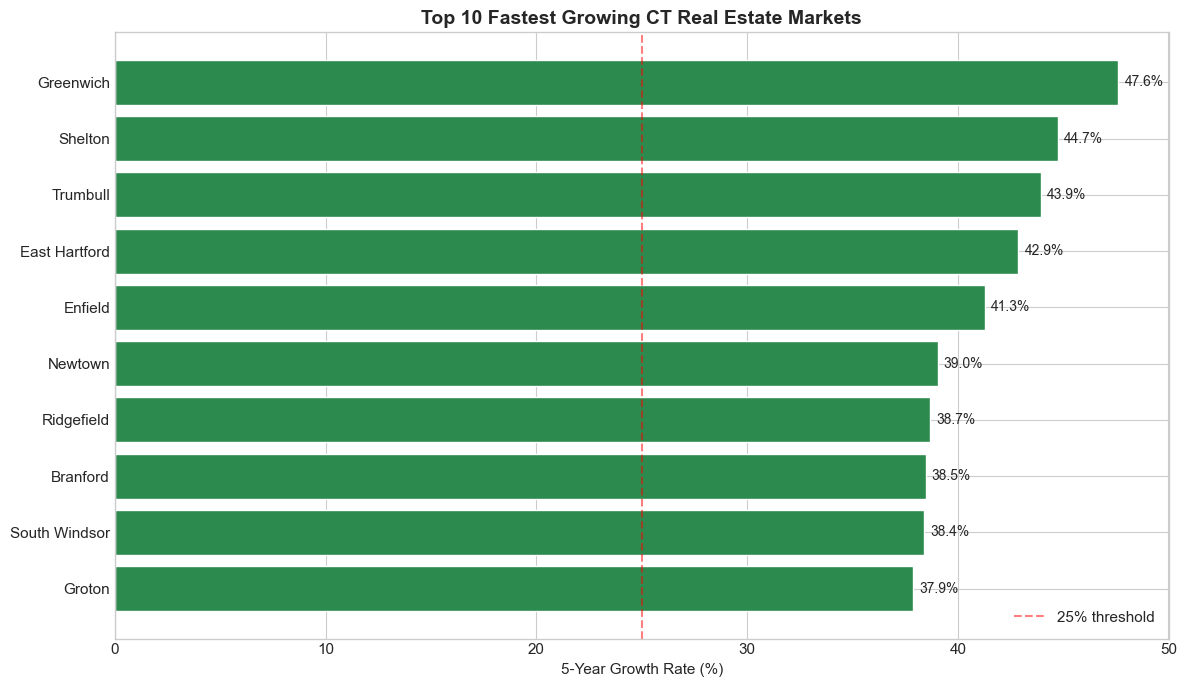

Greenwich leads at ~47.6% — nearly half of its all-time transactions happened in just the last 5 years.
That is a pretty strong signal that the market is accelerating, not just busy.


In [11]:
# clean column names
growth.columns = growth.columns.str.strip().str.replace('"'  , '')

fig, ax = plt.subplots(figsize=(12, 7))

towns = growth['town'].str.strip().str.replace('"', '')
rates = growth['past5yr_growth_rate'].astype(float)

bars = ax.barh(towns[::-1], rates[::-1] * 100, color='#2d8a4e', edgecolor='white')

for bar, rate in zip(bars, rates[::-1]):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            f'{rate*100:.1f}%', va='center', fontsize=10)

ax.set_xlabel('5-Year Growth Rate (%)')
ax.set_title('Top 10 Fastest Growing CT Real Estate Markets', fontweight='bold', fontsize=14)
ax.axvline(x=25, color='red', linestyle='--', alpha=0.5, label='25% threshold')
ax.legend()
plt.tight_layout()
plt.savefig('../images/growth_rate.png', dpi=150, bbox_inches='tight')
plt.show()

print("Greenwich leads at ~47.6% — nearly half of its all-time transactions happened in just the last 5 years.")
print("That is a pretty strong signal that the market is accelerating, not just busy.")

**Greenwich at 47.6%** is notable. Almost half of all Greenwich real estate transactions in the dataset's 20-year history happened in the last 5 years. That lines up with the post-COVID NYC exodus — wealthy families leaving Manhattan for Greenwich.

Shelton (44.7%) and Trumbull (43.9%) are interesting too. Both are in Fairfield County but more suburban/affordable than Greenwich. Could be people who got priced out of the coastal towns moving slightly inland.

## 5. Days on Market — Where Do Properties Sell Fastest?

Using Jan 1 of the list year as a proxy for the listing date (not perfect but it's what the data gives us). Lower = properties are moving faster.

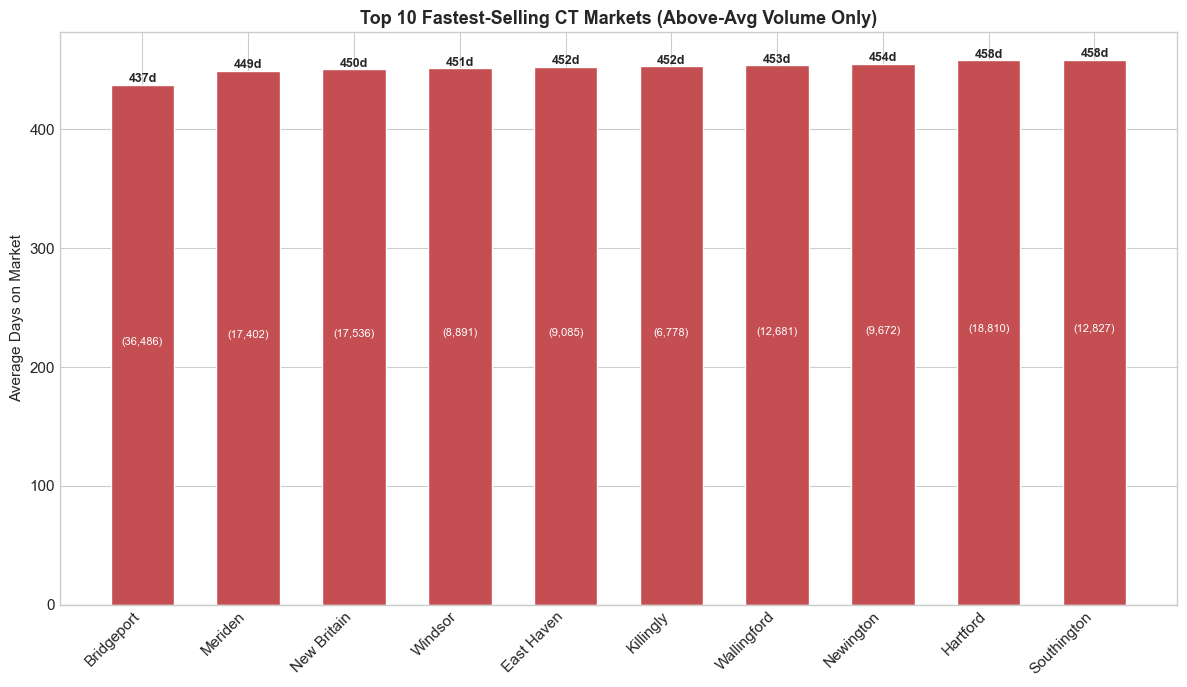

Spread between fastest and slowest in top 10: 21 days
All of these are roughly 14-15 months from listing to close — not dramatically different from each other.


In [12]:
days_market.columns = days_market.columns.str.strip().str.replace('"', '')
days_market['town'] = days_market['town'].str.strip().str.replace('"', '')
days_market['avg_days_on_market'] = days_market['avg_days_on_market'].astype(float)
days_market['total_properties'] = days_market['total_properties'].astype(int)

fig, ax1 = plt.subplots(figsize=(12, 7))

x = range(len(days_market))
bars = ax1.bar(x, days_market['avg_days_on_market'], color='#c44e52', edgecolor='white', width=0.6)

for i, (bar, props) in enumerate(zip(bars, days_market['total_properties'])):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
             f'{int(days_market["avg_days_on_market"].iloc[i]):.0f}d',
             ha='center', fontsize=9, fontweight='bold')
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height()/2,
             f'({props:,})', ha='center', fontsize=8, color='white')

ax1.set_xticks(x)
ax1.set_xticklabels(days_market['town'], rotation=45, ha='right')
ax1.set_ylabel('Average Days on Market')
ax1.set_title('Top 10 Fastest-Selling CT Markets (Above-Avg Volume Only)', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('../images/days_on_market.png', dpi=150, bbox_inches='tight')
plt.show()

spread = days_market['avg_days_on_market'].max() - days_market['avg_days_on_market'].min()
print(f"Spread between fastest and slowest in top 10: {spread:.0f} days")
print("All of these are roughly 14-15 months from listing to close — not dramatically different from each other.")

The top 10 fastest markets are all within a ~21 day range of each other (437 to 458 days). That tells me the "days on market" metric is pretty uniform across high-volume towns. The bigger differences probably show up when you compare these to smaller, rural towns that didn't make the cut.

Bridgeport at 437 days is the fastest, which tracks — high volume market, more affordable price points, probably quicker turns.

## 6. Sale Price Breakdown

Now for the money. Looking at sale prices across the top markets, broken down by property type. I filtered out anything above $138M (CT's all-time record sale) and anything with a weird sales ratio to keep the data clean.

In [13]:
sale_prices.columns = sale_prices.columns.str.strip().str.replace('"', '')
sale_prices['town'] = sale_prices['town'].str.strip().str.replace('"', '')
sale_prices['sale_amount'] = pd.to_numeric(sale_prices['sale_amount'].astype(str).str.replace('"', ''), errors='coerce')
sale_prices['property_type'] = sale_prices['property_type'].str.strip().str.replace('"', '')

# drop rows with missing/zero sale amounts
sale_prices = sale_prices[(sale_prices['sale_amount'] > 0) & (sale_prices['sale_amount'].notna())]

print("Property type breakdown:")
print(sale_prices['property_type'].value_counts())
print(f"Total transactions: {len(sale_prices):,}")
print(f"Median sale price: ${sale_prices['sale_amount'].median():,.0f}")
print(f"Mean sale price: ${sale_prices['sale_amount'].mean():,.0f}")

Property type breakdown:
property_type
Residential       9548
Single Family     8724
Vacant Land       1839
Condo             1476
Commercial        1267
Two Family         576
Three Family       162
Industrial         145
Apartments          73
Four Family         42
Public Utility       2
Name: count, dtype: int64
Total transactions: 23,854
Median sale price: $168,000
Mean sale price: $379,312


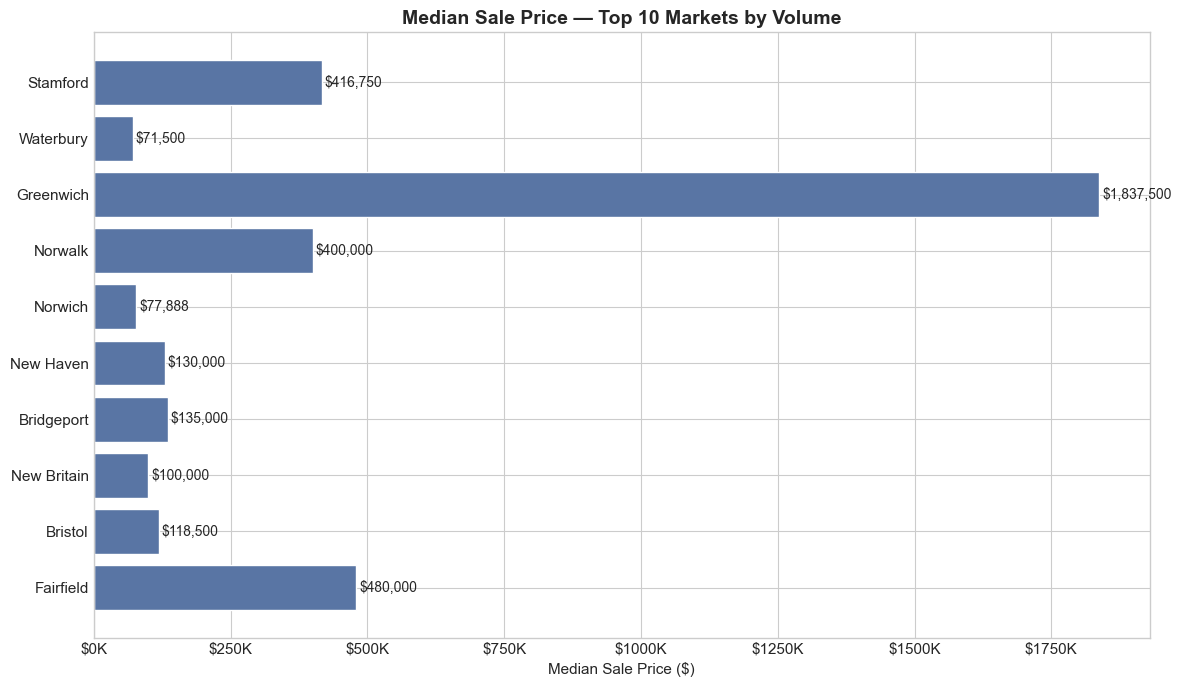

In [14]:
# median sale price for top 10 towns by transaction count
top_sale_towns = sale_prices['town'].value_counts().head(10).index.tolist()
top_prices = sale_prices[sale_prices['town'].isin(top_sale_towns)]

medians = top_prices.groupby('town')['sale_amount'].median().reindex(top_sale_towns)

fig, ax = plt.subplots(figsize=(12, 7))
bars = ax.barh(medians.index[::-1], medians.values[::-1], color='#5975a4', edgecolor='white')

for bar, val in zip(bars, medians.values[::-1]):
    ax.text(bar.get_width() + 5000, bar.get_y() + bar.get_height()/2,
            f'${val:,.0f}', va='center', fontsize=10)

ax.set_xlabel('Median Sale Price ($)')
ax.set_title('Median Sale Price — Top 10 Markets by Volume', fontweight='bold', fontsize=14)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
plt.tight_layout()
plt.savefig('../images/median_prices.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# box plot of sale prices by property type (log scale bc the range is huge)
main_types = ['Single Family', 'Residential', 'Commercial', 'Condo', 'Apartments']
type_data = sale_prices[sale_prices['property_type'].isin(main_types)]

fig, ax = plt.subplots(figsize=(12, 7))
bp_data = [type_data[type_data['property_type'] == t]['sale_amount'].dropna().values for t in main_types]
bp = ax.boxplot(bp_data, labels=main_types, patch_artist=True, showfliers=False)

colors = ['#5975a4', '#5f9e6e', '#c44e52', '#8172b3', '#ccb974']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.set_ylabel('Sale Price ($)')
ax.set_title('Sale Price Distribution by Property Type (outliers hidden)', fontweight='bold', fontsize=13)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
plt.tight_layout()
plt.savefig('../images/price_by_type.png', dpi=150, bbox_inches='tight')
plt.show()

# quick stats per type
for t in main_types:
    subset = type_data[type_data['property_type'] == t]['sale_amount']
    print(f"{t:15s} | Median: ${subset.median():>12,.0f} | Count: {len(subset):,}")

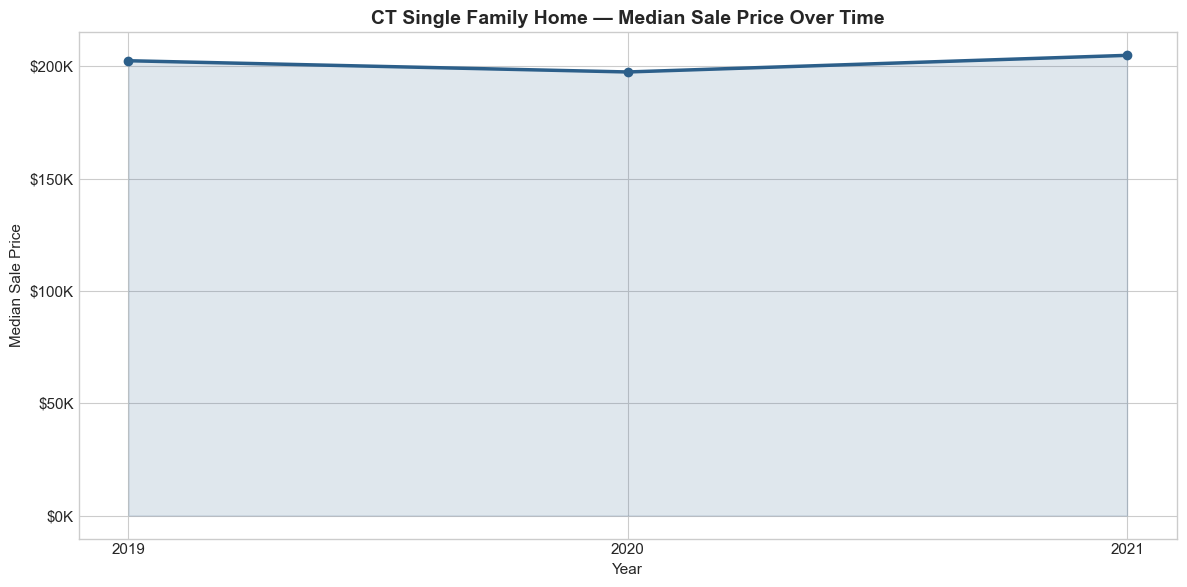

In [15]:
# load the sale price by year data for a time series view
prices_by_year = pd.read_csv('../data/processed/sale_price_by_year.csv')
prices_by_year.columns = prices_by_year.columns.str.strip().str.replace('"', '')
prices_by_year['sale_amount'] = pd.to_numeric(prices_by_year['sale_amount'].astype(str).str.replace('"', ''), errors='coerce')
prices_by_year['list_year'] = pd.to_numeric(prices_by_year['list_year'].astype(str).str.replace('"', ''), errors='coerce')
prices_by_year['property_type'] = prices_by_year['property_type'].str.strip().str.replace('"', '')

# median price per year for single family homes
sf = prices_by_year[prices_by_year['property_type'] == 'Single Family']
yearly_median = sf.groupby('list_year')['sale_amount'].median()

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(yearly_median.index, yearly_median.values, marker='o', linewidth=2.5,
        color='#2c5f8a', markersize=6)
ax.fill_between(yearly_median.index, yearly_median.values, alpha=0.15, color='#2c5f8a')

ax.set_xlabel('Year')
ax.set_ylabel('Median Sale Price')
ax.set_title('CT Single Family Home — Median Sale Price Over Time', fontweight='bold', fontsize=14)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
plt.tight_layout()
plt.savefig('../images/price_over_time.png', dpi=150, bbox_inches='tight')
plt.show()

## Key Findings

A few takeaways from all of this:

**1. COVID reshaped the market in a big way.** 2020 was a down year almost everywhere, then 2021 saw a massive spike in activity. This isn't unique to CT obviously, but the data shows it clearly — some towns saw swings of 500-900+ transactions year over year.

**2. Greenwich is the standout growth story.** Nearly half of its all-time transactions (47.6%) happened in the last 5 years. The Fairfield County corridor in general (Shelton, Trumbull, Ridgefield) is punching above its weight recently, likely driven by NYC remote workers.

**3. Volume and speed don't always correlate.** The "days on market" numbers across the top 10 towns are surprisingly tight (437-458 days avg). High-volume doesn't necessarily mean fast-selling — it just means more total deals.

**4. Single Family dominates.** In terms of transaction count, single family homes are the bulk of the market. Commercial deals are fewer but obviously much higher dollar values, which skews the mean.

**5. The 2022 cooldown is real.** After the 2021 surge, almost every market pulled back in 2022. Rising interest rates likely played a role here — the era of sub-3% mortgages was over.

---

### What I'd Do Next

- Pull in more recent data (2023-2024) to see if the cooldown continued or if things stabilized
- Break out the analysis by property type instead of just by town
- Build a proper regression model to predict days-on-market based on town, price, and property features
- Look at price-per-square-foot instead of raw sale price (need additional data for that)
- Cross-reference with census data to see if population growth correlates with market growth